# 01 — Data Acquisition

**Project:** VolatilityRegimes — Emerging Market Volatility Modeling  

**Purpose:** Pull raw time-series data from three sources (Banxico, Yahoo Finance, FRED), verify the API calls work, persist to `data/raw/`, and produce a first visual sanity check.  

**Output:** Three CSV files under DVC control; three plots confirming data integrity.

---

## 1. MXN/USD — Banxico FIX Rate

Source: Banco de México SIE API, series `SF43718`.  
This is the official FIX exchange rate published daily by Banxico — the rate used to settle foreign-currency obligations in Mexico. We prefer it over Yahoo Finance for the peso because it is the legally binding reference rate and has no survivorship or holiday gaps introduced by a third-party aggregator.

In [2]:
import os
import requests
from dotenv import load_dotenv
from datetime import date

load_dotenv()

BANXICO_TOKEN = os.getenv("BANXICO_TOKEN")

series = "SF43718"
start = "2000-01-01"
end = "2025-03-01"

url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{series}/datos/{start}/{end}"
headers = {"Bmx-Token": BANXICO_TOKEN}

response = requests.get(url, headers=headers)

print("Status:", response.status_code)
print("URL hit:", response.url)
print("Response preview:")
response.json()

Status: 200
URL hit: https://www.banxico.org.mx/SieAPIRest/service/v1/series/SF43718/datos/2000-01-01/2025-03-01
Response preview:


{'bmx': {'series': [{'idSerie': 'SF43718',
    'titulo': 'Tipo de cambio                                          Pesos por dólar E.U.A. Tipo de cambio para solventar obligaciones denominadas en moneda extranjera Fecha de determinación (FIX)',
    'datos': [{'fecha': '03/01/2000', 'dato': '9.3949'},
     {'fecha': '04/01/2000', 'dato': '9.4564'},
     {'fecha': '05/01/2000', 'dato': '9.5455'},
     {'fecha': '06/01/2000', 'dato': '9.5705'},
     {'fecha': '07/01/2000', 'dato': '9.5150'},
     {'fecha': '10/01/2000', 'dato': '9.4464'},
     {'fecha': '11/01/2000', 'dato': '9.4780'},
     {'fecha': '12/01/2000', 'dato': '9.5352'},
     {'fecha': '13/01/2000', 'dato': '9.5057'},
     {'fecha': '14/01/2000', 'dato': '9.4483'},
     {'fecha': '17/01/2000', 'dato': '9.4172'},
     {'fecha': '18/01/2000', 'dato': '9.4383'},
     {'fecha': '19/01/2000', 'dato': '9.4086'},
     {'fecha': '20/01/2000', 'dato': '9.4038'},
     {'fecha': '21/01/2000', 'dato': '9.4463'},
     {'fecha': '24/01/2000'

## 2. IPC Index — Yahoo Finance via yfinance

Ticker: `^MXX` (S&P/BMV IPC).  
The IPC (Índice de Precios y Cotizaciones) is Mexico's main equity benchmark, comprising the 35 most liquid stocks on the BMV. We use it alongside the exchange rate to capture both currency and equity market volatility dynamics.

In [3]:
import yfinance as yf

data = yf.download("^MXX", period="5y")

print(data.head())

Failed to get ticker '^MXX' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%%**********************]  1 of 1 completed

1 Failed download:
['^MXX']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


Empty DataFrame
Columns: [Open, High, Low, Close, Adj Close, Volume]
Index: []


We try some other approaches since the data is empty with the later cell.

In [4]:
ipc = fred.get_series("INDXMXBMI", observation_start="2000-01-01")
ipc.head()

NameError: name 'fred' is not defined

In [ ]:
import requests
import pandas as pd

url = "https://query1.finance.yahoo.com/v8/finance/chart/%5EMXX"
params = {
    "interval": "1d",
    "range": "25y"
}
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, params=params, headers=headers)
print("Status:", response.status_code)
print("Preview:", response.text[:500])

Status: 200
Preview: {"chart":{"result":[{"meta":{"currency":"MXN","symbol":"^MXX","exchangeName":"MEX","fullExchangeName":"Mexico","instrumentType":"INDEX","firstTradeDate":689607000,"regularMarketTime":1772834326,"hasPrePostMarketData":false,"gmtoffset":-21600,"timezone":"CST","exchangeTimezoneName":"America/Mexico_City","regularMarketPrice":67313.5,"fiftyTwoWeekHigh":72111.41,"fiftyTwoWeekLow":49799.28,"regularMarketDayHigh":68366.87,"regularMarketDayLow":67270.41,"regularMarketVolume":159702895,"longName":"IPC M


Apparently, yahoo's API is bugged for Mexican Market requests, a direct request is done and worked.

In [ ]:
import requests
import pandas as pd

url = "https://query1.finance.yahoo.com/v8/finance/chart/%5EMXX"
params = {
    "interval": "1d",
    "range": "25y"
}
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, params=params, headers=headers)
raw = response.json()

# Parse timestamps and closing prices
timestamps = raw["chart"]["result"][0]["timestamp"]
closes = raw["chart"]["result"][0]["indicators"]["quote"][0]["close"]

# Build DataFrame
df = pd.DataFrame({
    "IPC": closes
}, index=pd.to_datetime(timestamps, unit="s"))

df.index.name = "Date"
df.index = df.index.normalize()  # remove time component, keep date only

df.head()

## 3. Macro Indicators — FRED

Series pulled: `VIXCLS` (CBOE Volatility Index), `DFF` (Fed Funds Rate), `T10Y2Y` (yield spread).  
These are the external risk factors that drive peso volatility from outside Mexico. The VIX is particularly important: empirically, MXN/USD responds faster to VIX spikes than almost any other major currency pair.

In [ ]:
from fredapi import Fred

fred = Fred(api_key=os.getenv("FRED_API_KEY"))
vix = fred.get_series("VIXCLS", observation_start="2000-01-01")
vix.head()

2000-01-03    24.21
2000-01-04    27.01
2000-01-05    26.41
2000-01-06    25.73
2000-01-07    21.72
dtype: float64

## 4. Sanity Check — Visual Inspection

Before saving anything, we plot all three series.  
**What correct data looks like:**
- MXN/USD ~9–10 pesos/dollar in 2000, rising to ~17 by 2016 Trump shock, ~25 by 2020 COVID crash
- IPC growing from ~6,000 in 2000 to ~50,000+ by 2024
- VIX spiking sharply in 2008–09 and March 2020

If any series looks flat or wrong, **stop here** — downstream models will silently train on garbage.

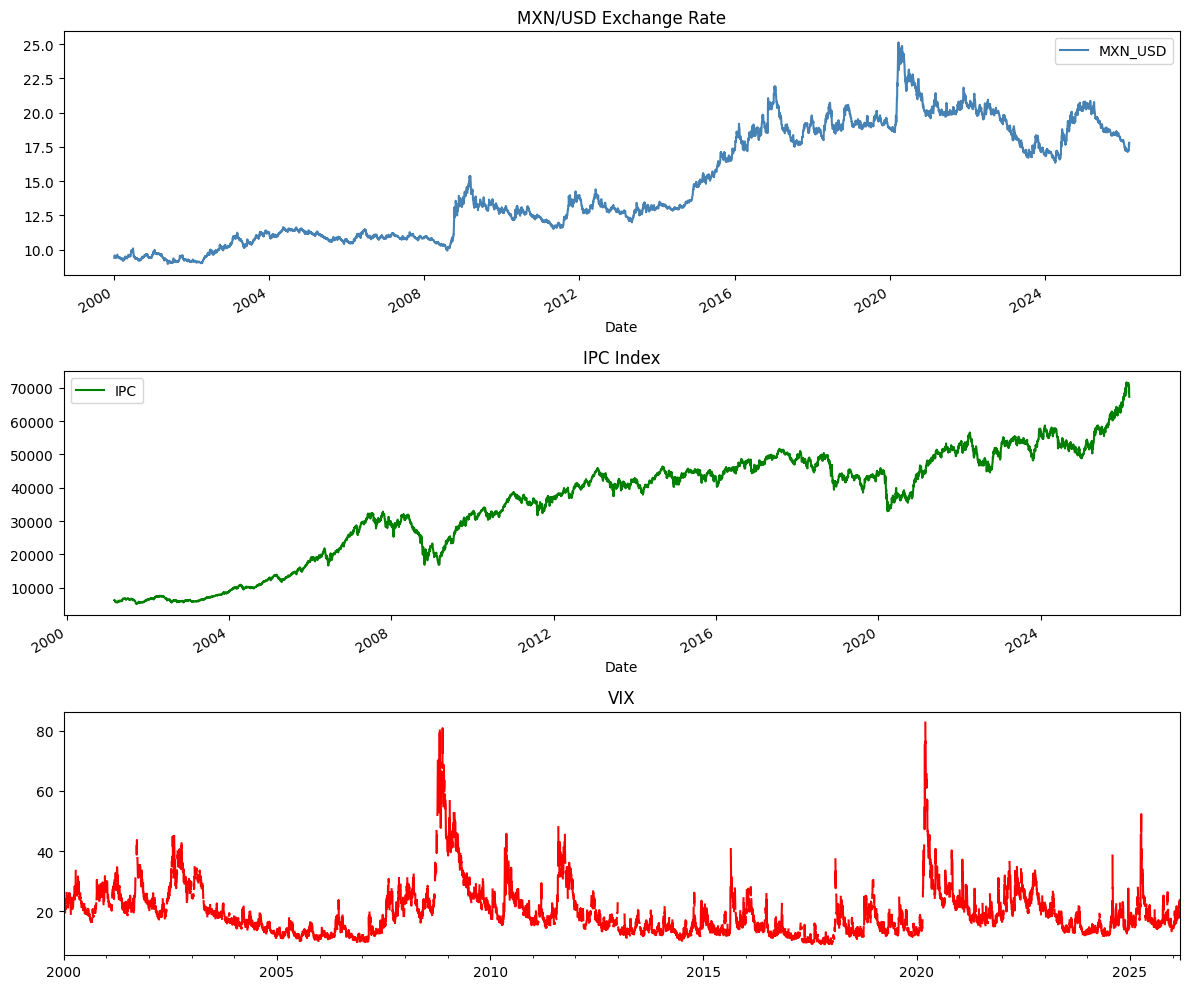

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path().resolve().parent

mxn = pd.read_csv(ROOT / "data/raw/mxn_usd.csv", index_col="Date", parse_dates=True)
ipc = pd.read_csv(ROOT / "data/raw/ipc.csv", index_col="Date", parse_dates=True)
macro = pd.read_csv(ROOT / "data/raw/macro.csv", index_col=0, parse_dates=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

mxn.plot(ax=axes[0], title="MXN/USD Exchange Rate", color="steelblue")
ipc.plot(ax=axes[1], title="IPC Index", color="green")
macro["VIXCLS"].plot(ax=axes[2], title="VIX", color="red")

plt.tight_layout()
plt.show()